In [129]:
from astropy import units as u
from pathlib import Path
from astropy.table import Table, vstack
import pandas as pd
from read_files import read_ipac_columns


PM_LIMIT = 200 # mas/year
W1_LIMIT = 17
output_dir = Path(f"/Volumes/PortableSSD/CatWISE-analysis/w1{W1_LIMIT:.0f}_pm{PM_LIMIT:.0f}_Q-4")
attemps = 10
Output_names = pd.read_csv(output_dir/"Output_names.csv")

Num = 0
for File in Output_names['File Name'].values:

    needed_cols = ['source_name']
    astropy_filtered = pd.read_csv(output_dir / File, usecols=needed_cols)
    # astropy_filtered = Table.read(output_dir / File, format="ascii.csv")
    print(f"{File} loaded with rows: {len(astropy_filtered)}")
    Num += len(astropy_filtered)
    
print(f"Total number of filtered sources: {Num}")

catwise_000_007_filtered.csv loaded with rows: 824369
catwise_008_015_filtered.csv loaded with rows: 738122
catwise_016_023_filtered.csv loaded with rows: 724557
catwise_024_031_filtered.csv loaded with rows: 781858
catwise_032_039_filtered.csv loaded with rows: 738396
catwise_040_047_filtered.csv loaded with rows: 678638
catwise_048_055_filtered.csv loaded with rows: 657077
catwise_056_063_filtered.csv loaded with rows: 629563
catwise_064_071_filtered.csv loaded with rows: 736510
catwise_072_079_filtered.csv loaded with rows: 918274
catwise_080_087_filtered.csv loaded with rows: 1168239
catwise_088_095_filtered.csv loaded with rows: 1196695
catwise_096_103_filtered.csv loaded with rows: 1167512
catwise_104_111_filtered.csv loaded with rows: 1097621
catwise_112_119_filtered.csv loaded with rows: 852064
catwise_120_127_filtered.csv loaded with rows: 795601
catwise_128_135_filtered.csv loaded with rows: 708872
catwise_136_143_filtered.csv loaded with rows: 637264
catwise_144_151_filtered

In [28]:
from pathlib import Path
import numpy as np
from tqdm import tqdm
import gzip

def count_ipac_rows(file_path):
    in_data = False
    n_rows = 0

    with gzip.open(file_path, "rt", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()

            if not s:
                continue

            # IPAC header/comment lines
            if not in_data:
                if s.startswith("\\") or s.startswith("|"):
                    continue
                in_data = True

            n_rows += 1

    return n_rows

Folders = np.arange(0, 359)
n_cat = 0
sources_cat = 0

for Folder in tqdm(Folders, desc="Folders", unit="folder"):
    path = Path(f"/Volumes/PortableSSD/CatWISE/2020/{Folder:03.0f}")
    catwise = sorted(f for f in path.iterdir() if f.is_file() and "_cat_" in f.name)
    sources_folder = 0

    for File in tqdm(catwise, desc=f"{Folder:03.0f}", unit="file", leave=False):
        n_rows = count_ipac_rows(File)
        sources_cat += n_rows
        sources_folder += n_rows

    print(f"{Folder:03.0f} has {sources_folder} sources.")

print(f"Total number of sources in CatWISE2020 catalog: {sources_cat}")

Folders:   0%|▏                                                                 | 1/359 [02:40<15:59:04, 160.74s/folder]

000 has 10563872 sources.



Folders:   1%|▎                                                                  | 2/359 [03:38<9:56:30, 100.25s/folder]

001 has 3882869 sources.



Folders:   1%|▎                                                                 | 2/359 [04:01<11:58:31, 120.76s/folder]


KeyboardInterrupt: 

In [30]:
import gzip
file='/Volumes/PortableSSD/CatWISE/2020/000/0000m016_opt1_20191208_213403_ab_v5_cat_b0.tbl.gz'
with gzip.open(file, "rt", encoding="utf-8", errors="replace") as f:
    for i in range(100):
        print(f"{i:02d}:", repr(next(f).rstrip("\n")))


00: '\\Nsrc = 65547  '
01: '\\ number of unWISE epochs engaged: 7 ascending, 6 descending'
02: '\\ bands engaged:   1  1  0  0'
03: '\\ zero mags(band):  22.500 22.500 22.500 12.000'
04: '\\ band =  1  standard Rap(band) =    8.25 arcsec ,      3.00 pix'
05: '\\ band =  2  standard Rap(band) =    8.25 arcsec ,      3.00 pix'
06: '\\ band =  1  circ apertures Rap =    5.50   8.25  11.00  13.75  16.50  19.25  22.00  24.75 arcsec ,      2.00   3.00   4.00   5.00   6.00   7.00   8.00   9.00 coadd pix'
07: '\\ band =  2  circ apertures Rap =    5.50   8.25  11.00  13.75  16.50  19.25  22.00  24.75 arcsec ,      2.00   3.00   4.00   5.00   6.00   7.00   8.00   9.00 coadd pix'
08: '\\ MJD0 = 57170.000000'
09: '\\ mrgad vsn 2.6  B91203 run on 12-08-19 at 21:34:03'
10: '\\ AllWISE flags retrieved from IRSA using 2.75 arcsec radius on 2019-12-08 21:21:48'
11: '\\ add-ab_flags vsn 2.6  B90204 run on 12-23-19 at 16:32:51'
12: '\\ artifact bitmasks from /Volumes/tyto1/Ab_masks_v1/unwise-0000m016-ms

In [36]:
for col in gaia.columns:
    print(col)


angDist
source_name
source_id
ra_pm
dec_pm
PMRA
PMDec
sigPMRA
sigPMDec
w1mpro_pm
w1sigmpro_pm
w2mpro_pm
w2sigmpro_pm
rchi2_pm
rchi2
w1rchi2_pm
w2rchi2_pm
pm_tot_masyr
ra_J2016
dec_J2016
DR3Name
RAdeg
DEdeg
errHalfMaj
errHalfMin
errPosAng
SolID
Source
RandomI
e_RAdeg
e_DEdeg
Plx
e_Plx
RPlx
PM
pmRA
e_pmRA
pmDE
e_pmDE
RADEcor
RAPlxcor
RApmRAcor
RApmDEcor
DEPlxcor
DEpmRAcor
DEpmDEcor
PlxpmRAcor
PlxpmDEcor
pmRApmDEcor
NAL
NAC
NgAL
NbAL
gofAL
chi2AL
epsi
sepsi
Solved
APF
nueff
pscol
e_pscol
RApscolCorr
DEpscolCorr
PlxpscolCorr
pmRApscolCorr
pmDEpscolCorr
MatchObsA
Nper
amax
MatchObs
IPDgofha
IPDgofhp
IPDfmp
IPDfow
RUWE
Dup
o_Gmag
FG
e_FG
RFG
Gmag
e_Gmag
o_BPmag
FBP
e_FBP
RFBP
BPmag
e_BPmag
o_RPmag
FRP
e_FRP
RFRP
RPmag
e_RPmag
E(BP/RP)
NBPcont
NBPblend
NRPcont
NRPblend
Mode
BP-RP
BP-G
G-RP
RV
e_RV
n_RV
o_RV
o_RVd
RVNper
RVS/N
RVgof
RVchi2
RVTdur
RVamp
RVtempTeff
RVtemplogg
RVtemp[Fe/H]
Vatmparam
vbroad
e_Vbroad
o_Vbroad
GRVSmag
e_GRVSmag
o_GRVSmag
RVSS/N
VarFlag
PQSO
PGal
PSS
Teff
b_Teff
B_Te

In [61]:
import pandas as pd
from pathlib import Path

PM_LIMIT = 500 # mas/year
W1_LIMIT = 17
output_dir = Path(f"/Volumes/PortableSSD/CatWISE-analysis/w1{W1_LIMIT:.0f}_pm{PM_LIMIT:.0f}_Q-4")
file = "CatWISE_GaiaDR3_2arcsec.csv"
gaia = pd.read_csv(output_dir/file)
gaia2 = gaia[["angDist", "source_name", "source_id", "ra_pm", "dec_pm", "PMRA", "PMDec", "sigPMRA", "sigPMDec", 'rchi2_pm', 'rchi2', 'w1rchi2_pm', 'w2rchi2_pm', 'pm_tot_masyr', "Plx", "e_Plx", "PM", "pmRA", "e_pmRA", "pmDE","e_pmDE","Gmag","e_Gmag"]]


In [63]:
unique_gaia = gaia2.drop_duplicates(subset="source_id", keep=False)
gaia3 = unique_gaia[~unique_gaia["pmRA"].isnull()]
gaia3[gaia3['PM']>=300]

,angDist,source_name,source_id,ra_pm,dec_pm,PMRA,PMDec,sigPMRA,sigPMDec,rchi2_pm,...,pm_tot_masyr,Plx,e_Plx,PM,pmRA,e_pmRA,pmDE,e_pmDE,Gmag,e_Gmag
11934,0.847344,J001347.26-393732.2,0038m394_b0-030157,3.446774,-39.626271,-0.18927,-0.97096,0.0787,0.0790,1.993000,...,989.235288,27.9029,0.1113,757.440002,-219.998,0.094,-724.787,0.105,17.877020,0.002969
28745,1.635595,J004755.69+474429.3,0112p484_b0-004632,11.984441,47.740342,1.40814,-0.93236,0.0209,0.0174,41.919998,...,1688.831972,28.2122,0.0259,860.508972,697.742,0.022,-503.620,0.020,14.576150,0.002806
41951,0.491254,J010617.00+114148.7,0169p121_b0-052382,16.570922,11.696807,0.30612,-0.46893,0.1215,0.1131,0.815200,...,560.004285,17.0811,0.3295,614.463989,476.049,0.425,-388.515,0.302,19.580528,0.004650
42111,0.191316,J010848.49+151512.9,0172p151_b0-027483,17.202086,15.253615,0.22510,-0.51736,0.0851,0.0759,0.856300,...,564.208631,6.8584,0.0690,541.377991,316.196,0.099,-439.443,0.060,16.721134,0.003024
42600,1.049197,J010922.58+294929.8,0173p302_b0-002308,17.345966,29.825295,1.69269,0.37284,0.0151,0.0173,57.529999,...,1733.265445,63.0080,0.1739,1076.223022,1011.269,0.157,368.227,0.131,17.565262,0.003232
68402,0.545062,J020512.30-051749.6,0318m046_b0-029232,31.302317,-5.296701,1.24108,0.52278,0.0745,0.0669,1.786000,...,1346.691685,31.0756,0.1566,1037.189941,960.115,0.180,392.355,0.139,18.107977,0.003094
82528,0.792536,J024634.14+162505.1,0408p166_b0-000388,41.640817,16.417011,-1.23877,-0.99786,0.0135,0.0134,67.230003,...,1590.684033,71.6048,0.0576,1007.588989,-831.533,0.060,-569.025,0.055,14.552517,0.002888
83664,0.527277,J024813.66-300128.1,0417m303_b0-048877,42.057039,-30.024374,0.45329,0.43900,0.0838,0.0924,0.772100,...,631.025217,12.7432,0.1636,550.143005,444.838,0.164,323.693,0.176,18.342787,0.003033
85535,0.608223,J025307.35-101905.0,0430m107_b0-000346,43.281062,-10.318815,0.74922,-0.96709,0.0129,0.0116,28.790001,...,1223.353455,40.9424,0.0332,634.783020,353.986,0.031,-526.919,0.033,14.463108,0.002895
85629,0.218146,J023738.01-844521.6,0432m849_b0-059308,39.407625,-84.755997,0.78883,-0.09681,0.0749,0.0752,0.645300,...,794.748353,16.3093,0.2740,765.083984,763.097,0.334,-55.107,0.334,19.579370,0.004570


In [101]:
chisq_ra = (gaia3['PMRA']-gaia3["pmRA"])**2/gaia3["sigPMRA"]**2
chisq_dec = (gaia3['PMDec']-gaia3["pmDE"])**2/gaia3["sigPMDec"]**2
chisq = (chisq_ra + chisq_dec)/2
((chisq_ra<=25) & (chisq_dec<=25)).sum()
(chisq<=25).sum()

58653

In [132]:
from astropy.time import Time
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import unique, Table
from astroquery.xmatch import XMatch
import pandas as pd

PM_LIMIT = 500 # mas/year
W1_LIMIT = 17
output_dir = Path(f"/Volumes/PortableSSD/CatWISE-analysis/w1{W1_LIMIT:.0f}_pm{PM_LIMIT:.0f}_Q-4")
Final_output_name = "CatWISE_VLASS_RACS-high_RACS-mid_2arcsec.csv"
#vizier names of catalogs
LoTSS_DR2 = "vizier:J/A+A/659/A1/catalog" # resolution is aruoud 6", sky coverage is ~27% of the northern sky (or 13.7% of the full sky)
VLASS1_QL = "vizier:J/ApJS/255/30/comp"  # best resolution is 2.5", suggested match radius 5", for objects that have dec >= −40° (33,885 deg^2)
RACS_high = "vizier:J/other/PASA/42.38/sourcesh" # resolution is around 11.8"×8.1", sky up to about Dec +48°, "vizier:J/other/PASA/42.38/gcomps" for Gaussian components
RACS_mid = "vizier:J/other/PASA/41.3/sourcesm" # "vizier:J/other/PASA/41.3/gcompsm" for Gaussian components
GaiaDR3 = "vizier:I/355/gaiadr3"
Galex_DR5 = "vizier:II/335/galex_ais" # this is revised version, original is "vizier:II/312/ais"
TwoMASS = "vizier:II/246/out" # catalogue for point sources.
CatWISE2020 = "vizier:II/365/catwise"

catwise_columns = ['angDist', 'source_name', 'source_id', 'ra_pm', 'dec_pm', 'PMRA', 'PMDec', 'sigPMRA', 'sigPMDec', 'w1mpro_pm', 'w1sigmpro_pm', 'w2mpro_pm', 'w2sigmpro_pm', 'rchi2_pm', 'rchi2', 'w1rchi2_pm', 'w2rchi2_pm', 'pm_tot_masyr']
vlass_columns = ['CompName', 'Ftot', 'e_Ftot', 'Fpeak', 'e_Fpeak']
racs_high_columns = ['Name', 'Ftot', 'Fpeak', 'Flag']
racs_mid_columns = ['RACS-MID1', 'Ftot', 'Fpeak', 'Flag']

catwise_rename = ['angDist', 'source_name', 'source_id', 'ra_pm', 'dec_pm', 'PMRA', 'PMDec', 'sigPMRA', 'sigPMDec', 'w1mpro_pm', 'w1sigmpro_pm', 'w2mpro_pm', 'w2sigmpro_pm', 'rchi2_pm', 'rchi2', 'w1rchi2_pm', 'w2rchi2_pm', 'pm_tot_masyr']
vlass_rename = ['VLASS_Name', 'VLASS_Ftot', 'VLASS_e_Ftot', 'VLASS_Fpeak', 'VLASS_e_Fpeak']
racs_high_rename = ['RACS-high_Name', 'RACSH_Ftot', 'RACSH_Fpeak', 'RACSH_Flag']
racs_mid_rename = ['RACS-mid1_Name', 'RACSM_Ftot', 'RACSM_Fpeak', 'RACSM_Flag']

file='CatWISE_VLASS_2arcsec.csv'
vlass_match=Table.read(output_dir/file, format='ascii.csv')
print(f"VLASS & CatWISE matches sources: {len(vlass_match)}")
vlass_match_unique = unique(vlass_match, keys='source_name', keep='first')
print(f"VLASS & CatWISE unique matches: {len(vlass_match_unique)}")

catwise_vlass = vlass_match_unique[catwise_columns+vlass_columns]
catwise_vlass.rename_columns(vlass_columns, vlass_rename)
catwise_vlass.rename_columns(catwise_columns, catwise_rename)
catwise_vlass.rename_columns(['angDist'], ['VLASS_angDist'])

coords=SkyCoord(
    ra=catwise_vlass["ra_pm"]*u.deg,
    dec=catwise_vlass["dec_pm"]*u.deg,
    pm_ra_cosdec=catwise_vlass['PMRA']*u.arcsec/u.yr,
    pm_dec = catwise_vlass['PMDec']*u.arcsec/u.yr,
    frame='icrs',
    obstime=Time(57170, format="mjd")
)

coord_new = coords.apply_space_motion(new_obstime=Time("J2022.15", format="jyear_str"))
catwise_vlass['RA_J2022.15']=coord_new.ra.deg
catwise_vlass['DE_J2022.15']=coord_new.dec.deg

RACS_high_match = XMatch.query(
    cat1=catwise_vlass,
    cat2=RACS_high,
    max_distance=2 * u.arcsec,  
    colRA1='RA_J2022.15',
    colDec1='DE_J2022.15',
    colRA2="RAJ2000", 
    colDec2="DEJ2000"
)
print(f"RACS_high & VLASS & CatWISE matches: {len(RACS_high_match)}")
RACS_high_match_unique = unique(RACS_high_match, keys='source_name', keep='first')
print(f"RACS_high & VLASS & CatWISE unique matches: {len(RACS_high_match_unique)}")
catwise_vlass_racs_high = RACS_high_match_unique[['angDist'] + catwise_vlass.colnames[:-2] + racs_high_columns]
catwise_vlass_racs_high.rename_columns(racs_high_columns, racs_high_rename)
catwise_vlass_racs_high.rename_columns(['angDist'], ['RACSH_angDist'])

coords=SkyCoord(
    ra=catwise_vlass_racs_high["ra_pm"]*u.deg,
    dec=catwise_vlass_racs_high["dec_pm"]*u.deg,
    pm_ra_cosdec=catwise_vlass_racs_high['PMRA']*u.arcsec/u.yr,
    pm_dec = catwise_vlass_racs_high['PMDec']*u.arcsec/u.yr,
    frame='icrs',
    obstime=Time(57170, format="mjd")
)

coord_new = coords.apply_space_motion(new_obstime=Time("J2021.5", format="jyear_str"))
catwise_vlass_racs_high['RA_J2021.5']=coord_new.ra.deg
catwise_vlass_racs_high['DE_J2021.5']=coord_new.dec.deg

RACS_mid_match = XMatch.query(
    cat1=catwise_vlass_racs_high,
    cat2=RACS_mid,
    max_distance=2 * u.arcsec,  
    colRA1='RA_J2021.5',
    colDec1='DE_J2021.5',
    colRA2="RAJ2000", 
    colDec2="DEJ2000"
)
print(f"RACS_mid & RACS_high & VLASS & CatWISE matches: {len(RACS_mid_match)}")
RACS_mid_match_unique = unique(RACS_mid_match, keys='source_name', keep='first')
print(f"RACS_mid & RACS_high & VLASS & CatWISE unique matches: {len(RACS_mid_match_unique)}")
catwise_vlass_racs_high_racs_mid = RACS_mid_match[['angDist'] + catwise_vlass_racs_high.colnames[:-2] + racs_mid_columns]
catwise_vlass_racs_high_racs_mid.rename_columns(racs_mid_columns, racs_mid_rename)
catwise_vlass_racs_high_racs_mid.rename_columns(['angDist'], ['RACSM_angDist'])
catwise_vlass_racs_high_racs_mid.write(output_dir/Final_output_name, overwrite=True)
print(f"Final output is saved in {output_dir/Final_output_name}.")

VLASS & CatWISE matches sources: 4961
VLASS & CatWISE unique matches: 4569
RACS_high & VLASS & CatWISE matches: 262
RACS_high & VLASS & CatWISE unique matches: 262
RACS_mid & RACS_high & VLASS & CatWISE matches: 179
RACS_mid & RACS_high & VLASS & CatWISE unique matches: 179
Final output is saved in /Volumes/PortableSSD/CatWISE-analysis/w117_pm500_Q-4/CatWISE_VLASS_RACS-high_RACS-mid_2arcsec.csv.


/opt/anaconda3/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "pmsafe" yielded 4568 of "distance overridden (Note 6)", 1 of "binary logical OR of the above warnings"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/opt/anaconda3/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "pmsafe" yielded 262 of "distance overridden (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [189]:
from astropy.table import Table

PM_LIMIT = 500 # mas/year
W1_LIMIT = 16
output_dir = Path(f"/Volumes/PortableSSD/CatWISE-analysis/w1{W1_LIMIT:.0f}_pm{PM_LIMIT:.0f}_Q-4")
Final_output_name = "CatWISE_VLASS_RACS-high_RACS-mid_2arcsec.csv"
table = Table.read(output_dir/Final_output_name)
Total = len(table)
print(f"Total number of sources: {Total:0.0f}.")
Stat1 = len(table[(table['w1rchi2_pm']<2) & (table['w2rchi2_pm']<2)])
print(f"{Stat1/Total * 100:0.0f}% of sources satisfy 'w1rchi2_pm<2 and w1rchi2_pm<2' condition.")
Stat2 = len(table[table['rchi2']/table['rchi2_pm']>1.03])
print(f"{Stat2/Total * 100:0.0f}% of sources satisfy 'rchi2/rchi2_pm>1.03' condition.")
Stat3 = len(table[(table['w1rchi2_pm']<2) & (table['w2rchi2_pm']<2) & (table['rchi2']/table['rchi2_pm']>1.03)])
print(f"{Stat3/Total * 100:0.0f}% of sources satisfy both of the above-mentioned conditions.")

Total number of sources: 216.
89% of sources satisfy 'w1rchi2_pm<2 and w1rchi2_pm<2' condition.
57% of sources satisfy 'rchi2/rchi2_pm>1.03' condition.
50% of sources satisfy both of the above-mentioned conditions.


In [163]:
# Cross-match with SIMBAD

import pandas as pd
import warnings
from pathlib import Path

from astroquery.simbad import Simbad
from astroquery.exceptions import NoResultsWarning

from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u

warnings.filterwarnings("ignore", category=NoResultsWarning)

PM_LIMIT = 200  # mas/year
W1_LIMIT = 17
output_dir = Path(f"/Volumes/PortableSSD/CatWISE-analysis/w1{W1_LIMIT:.0f}_pm{PM_LIMIT:.0f}_Q-4")

# --- read and prepare input table ---
file = Table.read(output_dir / "CatWISE_VLASS_RACS-high_RACS-mid_2arcsec.csv")

coords = SkyCoord(
    ra=file["ra_pm"] * u.deg,
    dec=file["dec_pm"] * u.deg,
    pm_ra_cosdec=file["PMRA"] * u.arcsec / u.yr,
    pm_dec=file["PMDec"] * u.arcsec / u.yr,
    frame="icrs",
    obstime=Time(57170, format="mjd"),
)

coord_new = coords.apply_space_motion(new_obstime=Time("J2000", format="jyear_str"))
file["RA_J2000"] = coord_new.ra.deg
file["DE_J2000"] = coord_new.dec.deg

table = file.to_pandas()

# --- SIMBAD setup ---
custom_simbad = Simbad()
custom_simbad.ROW_LIMIT = 50
custom_simbad.TIMEOUT = 60
custom_simbad.add_votable_fields("pmra", "pmdec", "plx_value", "plx_err", "otype")
wanted = ["main_id", "ra", "dec", "pmra", "pmdec", "plx_value", "plx_err", "otype"]
all_rows = []

for source in table.itertuples(index=False):
    ra = source.RA_J2000
    dec = source.DE_J2000

    query_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
    result = custom_simbad.query_region(query_coord, radius=5 * u.arcsec)

    if result is None:
        continue

    result_df = result.to_pandas()
    result_df = result_df[[c for c in wanted if c in result_df.columns]].copy()

    # vectorized angular separation
    simbad_coords = SkyCoord(
        ra=result_df["ra"].to_numpy() * u.deg,
        dec=result_df["dec"].to_numpy() * u.deg,
        frame="icrs",
    )
    result_df["angular_distance"] = query_coord.separation(simbad_coords).arcsecond
    result_df = result_df.sort_values("angular_distance", ignore_index=True)
    
    original_columns = ["source_id", "PMRA", "sigPMRA", "PMDec", "sigPMDec", 'rchi2', 'rchi2_pm', 'w1rchi2_pm', 'w2rchi2_pm']
    for i, col in enumerate(original_columns):
        result_df.insert(i, col, getattr(source, col))

    all_rows.append(result_df)

tab = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
tab.to_csv(output_dir/'SIMBAD-match.csv', index=False)
tab

/opt/anaconda3/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "pmsafe" yielded 651 of "distance overridden (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


,source_id,PMRA,sigPMRA,PMDec,sigPMDec,rchi2_pm,w1rchi2_pm,w2rchi2_pm,main_id,ra,dec,pmra,pmdec,plx_value,plx_err,otype,angular_distance
0,0106m061_b0-019951,0.02834,0.0621,-0.27889,0.0609,0.8728,0.9228,0.8344,FIRST J004001.9-052606,10.007879,-5.435034,NaN,NaN,NaN,NaN,AG?,4.995579
1,0123p318_b0-028687,-0.20480,0.0472,0.02006,0.0412,0.9667,1.1110,0.8345,NVSS J004751+313701,11.963210,31.616770,NaN,NaN,NaN,NaN,Rad,3.064969
2,0127p348_b0-035566,0.20149,0.0591,-0.17722,0.0574,0.9101,0.7575,1.0760,NVSS J005353+345058,13.471914,34.849480,NaN,NaN,NaN,NaN,Rad,4.934537
3,0168p090_b0-022119,0.22379,0.0607,-0.16083,0.0593,0.8882,0.8030,0.9860,FIRST J010622.7+090513,16.594797,9.087202,NaN,NaN,NaN,NaN,AG?,4.293468
4,0166p257_b0-048940,-0.31636,0.0910,0.23580,0.0850,0.7920,0.6884,0.9063,SDSS J010754.97+261427.1,16.979045,26.240866,NaN,NaN,NaN,NaN,QSO,4.646708
5,0200p121_b0-022026,-0.00247,0.0526,-0.25471,0.0540,0.9247,0.8721,0.9889,SDSS J012249.34+122257.8,20.705624,12.382735,NaN,NaN,NaN,NaN,QSO,4.004838
6,0258p212_b0-020925,0.04818,0.0514,0.24263,0.0518,1.0480,1.0180,1.0910,NVSS J014022+204138,25.092410,20.693520,NaN,NaN,NaN,NaN,Rad,2.996200
7,0330m167_b0-035650,-0.19836,0.0620,-0.18855,0.0627,0.9113,0.9507,0.8840,NVSS J021151-161458,32.964870,-16.249530,NaN,NaN,NaN,NaN,Rad,4.429873
8,0350m258_b0-027254,0.01750,0.0651,-0.23776,0.0527,1.1220,1.0820,1.1760,NVSS J022022-252525,35.093800,-25.423830,NaN,NaN,NaN,NaN,Rad,3.334535
9,0516m046_b0-034636,0.26979,0.0585,0.06195,0.0705,1.7900,2.4660,1.1320,NVSS J032658-045428,51.742975,-4.907950,NaN,NaN,NaN,NaN,Rad,1.902640


In [162]:
tab.drop_duplicates(subset="source_id", keep='first')


,source_id,PMRA,sigPMRA,PMDec,sigPMDec,rchi2_pm,w1rchi2_pm,w2rchi2_pm,main_id,ra,dec,pmra,pmdec,plx_value,plx_err,otype,angular_distance
0,2032p136_b0-012396,-0.18270,0.0246,-0.12775,0.0291,1.6240,1.6590,1.6100,FIRST J133523.5+130512,203.848217,13.086668,NaN,NaN,NaN,NaN,AG?,3.404913
1,2050m213_b0-023474,-0.20665,0.0440,-0.04039,0.0479,1.1680,1.3620,0.9891,PMN J1340-2146,205.020580,-21.767210,NaN,NaN,NaN,NaN,Rad,3.703623
2,2050m152_b0-020014,-0.18898,0.0428,0.10539,0.0537,1.6160,1.7870,1.4650,CRTS MLS120330 J134313-144640,205.805458,-14.777861,NaN,NaN,NaN,NaN,Bla,3.307063
3,2089p363_b0-024252,-0.21584,0.0556,-0.15785,0.0606,0.7926,0.5972,1.0000,NVSS J135250+365319,208.211396,36.888742,NaN,NaN,NaN,NaN,Rad,4.585212
4,2096m061_b0-010589,-0.24206,0.0431,0.08972,0.0517,1.3680,1.4290,1.3250,NVSS J140029-055221,210.121896,-5.872703,NaN,NaN,NaN,NaN,Rad,3.767475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,2011p015_b0-015119,-0.24443,0.0382,0.02520,0.0514,0.8814,0.8548,0.9201,NVSS J132420+020324,201.083737,2.057253,NaN,NaN,NaN,NaN,Rad,4.018782
167,2011p030_b0-024388,0.10869,0.0589,-0.23843,0.0523,0.9734,0.7558,1.2050,GLEAM J132430+030346,201.125340,3.063090,NaN,NaN,NaN,NaN,Rad,3.979538
168,2017p212_b0-015535,-0.00727,0.0469,-0.22124,0.0497,0.7969,0.8817,0.7231,FIRST J132511.5+203146,201.298252,20.529652,NaN,NaN,NaN,NaN,AG?,3.365616
169,2030p106_b0-009903,0.20329,0.0284,0.14776,0.0325,1.3210,1.6540,1.0060,FIRST J132929.8+103738,202.374441,10.627191,NaN,NaN,NaN,NaN,AG?,3.875754


In [146]:
from astropy.coordinates import SkyCoord
import astropy.units as u

File = Table.read('CatWISE_VLASS_RACS-high_RACS-mid_2arcsec.csv')
ra=File['RA_ICRS']
dec=File['DE_ICRS']
c_icrs = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')
c_gal = c_icrs.galactic

# final = vlass_racs_lofar.copy()
# final.insert(final.columns.get_loc('otype') + 1, 'l',c_gal.l.deg)
# final.insert(final.columns.get_loc('l') + 1, 'b', c_gal.b.deg)
# final.to_csv(f'{path}/final_match_full.csv', index=False)

c_gal.l

<Longitude [106.77341256,  98.99540371,  86.89800391, 113.28424129,
             35.00261246, 338.55966799,  74.38137667, 103.32459178,
            113.72363402, 114.33281626, 107.47115414, 107.08282711,
            107.08282711, 111.37785117, 111.05385121,  96.16394988,
            112.61331532, 101.87099902, 115.30335122,  89.57028732,
             89.57028732, 326.88700562,  77.50295279, 117.34953411,
            123.71009124, 121.62143761, 125.99250755, 124.17484082,
            265.90878266, 125.94517403, 134.19485458, 134.61946503,
            133.02420403, 284.85611429, 127.50214994, 132.89619613,
            148.92581667, 162.05069889, 256.29395032, 149.58894696,
            159.2676601 , 132.23830081, 160.31133578, 133.5380182 ,
            152.97732376, 179.56825731, 213.04437242, 194.11917649,
            171.01773548, 194.3485645 , 171.19151247, 208.98551021,
            231.17739258, 245.03723237, 228.9109568 , 163.25125165,
            189.93408866, 225.89937422, 168.7987

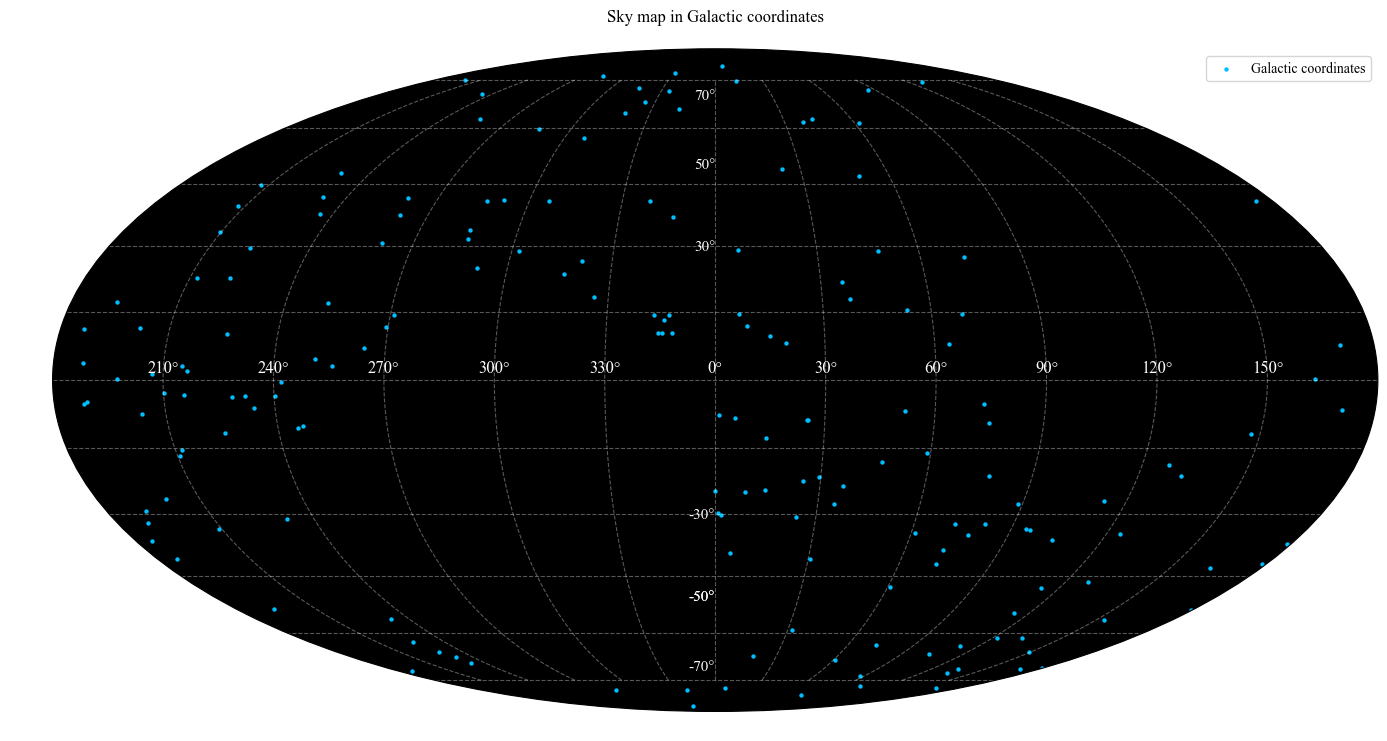

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'text.usetex': False,   # safer unless you know your LaTeX install works
})

# Read table
tbl = Table.read(output_dir/'CatWISE_VLASS_RACS-high_RACS-mid_2arcsec.csv')

# Build ICRS coordinates
c_icrs = SkyCoord(
    ra=tbl['ra_pm'] * u.deg,
    dec=tbl['dec_pm'] * u.deg,
    frame='icrs'
)

# Convert to Galactic
c_gal = c_icrs.galactic

# Wrap longitude to [-180, 180] for Mollweide
l_rad = c_gal.l.wrap_at(180 * u.deg).radian
b_rad = c_gal.b.radian

# Wrap longitude to [-180, 180] for Mollweide
ra_rad = c_icrs.ra.wrap_at(180 * u.deg).radian
dec_rad = c_icrs.dec.radian

# Plot
fig = plt.figure(figsize=(14, 8), facecolor='white')
# Aitoff/hammer/mollweide
ax = fig.add_subplot(111, projection='mollweide')
ax.set_facecolor('black')

ax.scatter(
    l_rad,
    b_rad,
    s=10,
    color='deepskyblue',
    alpha=1,
    linewidths=0,
    label="Galactic coordinates"
)

# ax.scatter(
#     ra_rad,
#     dec_rad,
#     s=10,
#     color='red',
#     alpha=1,
#     linewidths=0,
#     label="Equatorial coordinates"
# )

# Grid
ax.grid(True, color='white', linestyle='--', alpha=0.35)

# Galactic longitude ticks (in degrees)
xticks_deg = np.arange(-150, 180, 30)
ax.set_xticks(np.radians(xticks_deg))
ax.set_xticklabels([f'{(x % 360):d}°' for x in xticks_deg], color='white')

# Y ticks
for y in [-70, -50, -50, -30, 30, 50, 70]:
    ax.text(
        np.radians(+0),   # left edge
        np.radians(y),
        f"{y}°",
        color='white',
        fontsize=11,
        ha='right',
        va='center'
    )

# Latitude tick colors
ax.tick_params(colors='white', labelsize=12)

# Labels
ax.set_xlabel('Galactic Longitude', color='white')
ax.set_ylabel('Galactic Latitude', color='white')
ax.set_title('Sky map in Galactic coordinates', color='black', pad=20)
plt.legend()
# plt.savefig(output_dir/f'sky-map_galactic.pdf', dpi=300, facecolor='white', bbox_inches='tight')
plt.tight_layout()
plt.show()

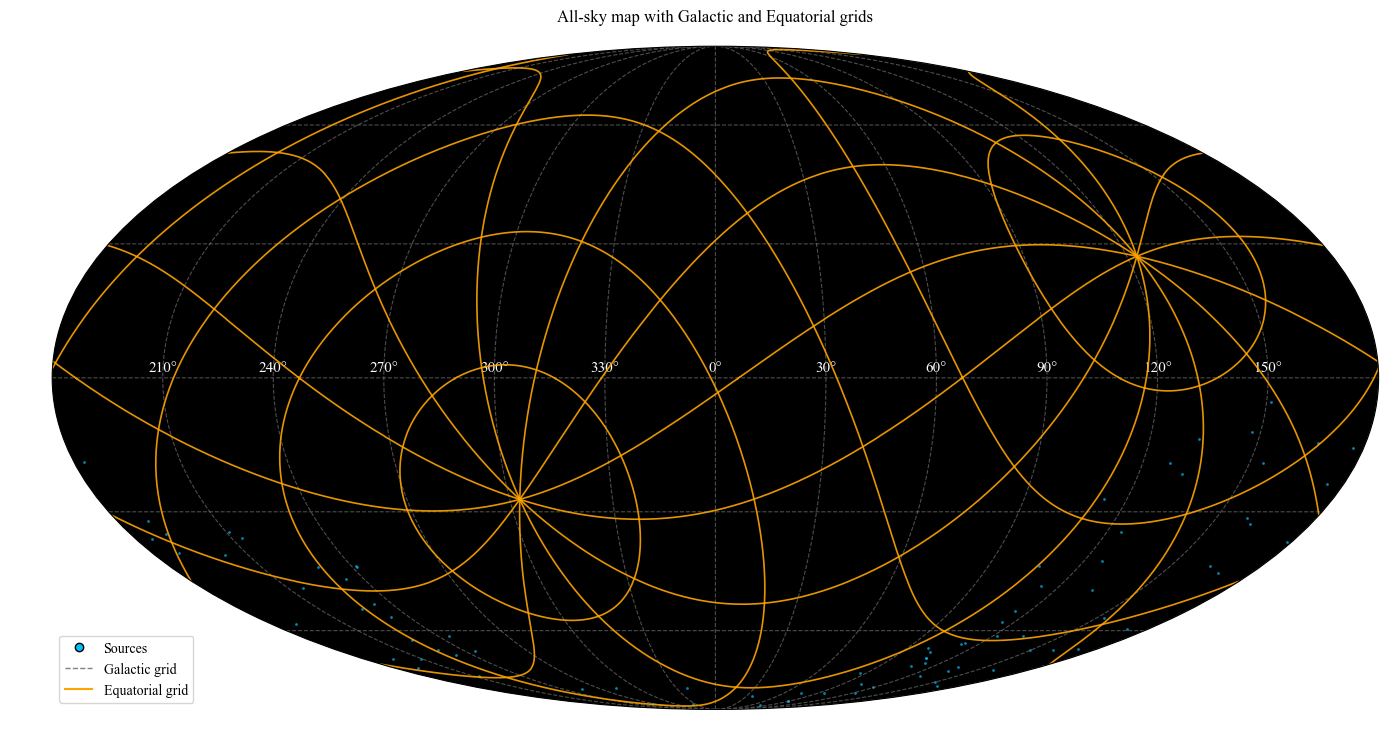

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from matplotlib.lines import Line2D

# -----------------------------
# Load catalog and convert source positions
# -----------------------------
tbl = Table.read('CatWISE_VLASS_RACS-high_RACS-mid_2arcsec.csv')

c_icrs = SkyCoord(
    ra=tbl['RA_ICRS'] * u.deg,
    dec=tbl['DE_ICRS'] * u.deg,
    frame='icrs'
)
c_gal = c_icrs.galactic

# Source positions in radians for Mollweide
l_src = c_gal.l.wrap_at(180 * u.deg).radian
b_src = c_gal.b.radian

# -----------------------------
# Helper: split lines at longitude wrap
# -----------------------------
def plot_wrapped_line(ax, lon_rad, lat_rad, **kwargs):
    lon_rad = np.asarray(lon_rad)
    lat_rad = np.asarray(lat_rad)

    jumps = np.where(np.abs(np.diff(lon_rad)) > np.pi)[0]
    start = 0
    for j in jumps:
        ax.plot(lon_rad[start:j+1], lat_rad[start:j+1], **kwargs)
        start = j + 1
    ax.plot(lon_rad[start:], lat_rad[start:], **kwargs)

# -----------------------------
# Figure
# -----------------------------
fig = plt.figure(figsize=(14, 8), facecolor='white')
ax = fig.add_subplot(111, projection='mollweide')
ax.set_facecolor('black')

# Sources
ax.scatter(
    l_src,
    b_src,
    s=4,
    color='deepskyblue',
    alpha=0.7,
    linewidths=0
)

# -----------------------------
# Galactic grid
# -----------------------------
# Constant b lines
l_vals = np.linspace(-180, 180, 1000)
for b0 in [-60, -30, 0, 30, 60]:
    lon = np.radians(l_vals)
    lat = np.full_like(lon, np.radians(b0))
    ax.plot(lon, lat, color='gray', lw=0.8, ls='--', alpha=0.6)

# Constant l lines
b_vals = np.linspace(-90, 90, 500)
for l0 in np.arange(-150, 181, 30):
    lon = np.full_like(b_vals, np.radians(l0))
    lat = np.radians(b_vals)
    ax.plot(lon, lat, color='gray', lw=0.8, ls='--', alpha=0.6)

# -----------------------------
# Equatorial grid transformed into Galactic
# -----------------------------
# Constant Dec lines
ra_line = np.linspace(0, 360, 1500) * u.deg
for dec0 in [-60, -30, 0, 30, 60]:
    eq_line = SkyCoord(
        ra=ra_line,
        dec=np.full(len(ra_line), dec0) * u.deg,
        frame='icrs'
    )
    gal_line = eq_line.galactic
    lon = gal_line.l.wrap_at(180 * u.deg).radian
    lat = gal_line.b.radian
    plot_wrapped_line(ax, lon, lat, color='orange', lw=1.2, alpha=0.9)

# Constant RA lines
dec_line = np.linspace(-89.9, 89.9, 1000) * u.deg
for ra0 in np.arange(0, 360, 30):
    eq_line = SkyCoord(
        ra=np.full(len(dec_line), ra0) * u.deg,
        dec=dec_line,
        frame='icrs'
    )
    gal_line = eq_line.galactic
    lon = gal_line.l.wrap_at(180 * u.deg).radian
    lat = gal_line.b.radian
    plot_wrapped_line(ax, lon, lat, color='orange', lw=1.2, alpha=0.9)

# -----------------------------
# Formatting
# -----------------------------
xticks_deg = np.arange(-150, 180, 30)
ax.set_xticks(np.radians(xticks_deg))
ax.set_xticklabels([f'{x % 360:.0f}°' for x in xticks_deg], color='white')

ax.tick_params(colors='white', labelsize=11)
ax.set_xlabel('Galactic Longitude $l$', color='white')
ax.set_ylabel('Galactic Latitude $b$', color='white')
ax.set_title('All-sky map with Galactic and Equatorial grids', pad=18)

legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='deepskyblue',
           markersize=6, label='Sources'),
    Line2D([0], [0], color='gray', lw=1, ls='--', label='Galactic grid'),
    Line2D([0], [0], color='orange', lw=1.5, label='Equatorial grid'),
]
ax.legend(handles=legend_handles, loc='lower left')

plt.tight_layout()
plt.show()


In [90]:
'asfawxfHGHU'.lower()

'asfawxfhghu'

In [123]:
from pathlib import Path
from astropy.table import Table
import pandas as pd

path = Path('/Volumes/PortableSSD/CatWISE-analysis/w117_pm200_Q-4')

List_names = list(path.iterdir())
List_names=[]
for i, _ in enumerate(List[:-2]):
    List_names.append(List[i].name)

# List_names=pd.DataFrame({"File Name": List_names})

In [125]:
pd.DataFrame({"File Name": List_names}).to_csv(List[-2], index=False)

In [120]:
List_names

,0
0,catwise_000_007_filtered.csv
1,catwise_008_015_filtered.csv
2,catwise_016_023_filtered.csv
3,catwise_024_031_filtered.csv
4,catwise_032_039_filtered.csv
5,catwise_040_047_filtered.csv
6,catwise_048_055_filtered.csv
7,catwise_056_063_filtered.csv
8,catwise_064_071_filtered.csv
9,catwise_072_079_filtered.csv
